In [ ]:
!pip install kagglehub nibabel scikit-image

In [ ]:
import os
import tarfile
import kagglehub
import numpy as np
import nibabel as nib
import cv2
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
base = kagglehub.dataset_download("dschettler8845/brats-2021-task1")

extract = "/content/brats"
os.makedirs(extract, exist_ok=True)

for f in os.listdir(base):
    if f.endswith(".tar"):
        with tarfile.open(os.path.join(base,f)) as t:
            t.extractall(extract)

Using Colab cache for faster access to the 'brats-2021-task1' dataset.


/tmp/ipykernel_160/3175939371.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(extract)


In [ ]:
def load_brats(path,max_patients=20):

    images=[]

    patients=[
        p for p in os.listdir(path)
        if os.path.isdir(os.path.join(path,p)) and not p.startswith(".")
    ]

    patients=sorted(patients)[:max_patients]

    for p in patients:

        flair_file=os.path.join(path,p,p+"_flair.nii.gz")

        if not os.path.exists(flair_file):
            continue

        flair=nib.load(flair_file).get_fdata()

        for i in range(40,120):
            images.append(flair[:,:,i])

    return np.array(images)

X=load_brats(extract)
print("Loaded:",X.shape)

Loaded: (1600, 240, 240)


In [ ]:
import cv2
import numpy as np

def resize_images(images):

    resized = []

    for img in images:
        resized.append(cv2.resize(img,(96,96)))

    return np.array(resized)

X_small = resize_images(X)

print("Resized:", X_small.shape)

Resized: (1600, 96, 96)


In [ ]:
mean = X_small.mean()
std = X_small.std()

X_small = (X_small - mean) / (std + 1e-8)

In [ ]:
from sklearn.decomposition import PCA

X_vec = X_small.reshape(len(X_small), -1)

pca = PCA(n_components=512)

Z = pca.fit_transform(X_vec)

print("Latent shape:", Z.shape)

Latent shape: (1600, 512)


In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Z_tensor = torch.tensor(Z, dtype=torch.float32)

dataset = TensorDataset(Z_tensor)

loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [ ]:
import torch.nn as nn

class Encoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(512,1024),
            nn.ReLU(),

            nn.Linear(1024,256)
        )

    def forward(self,x):

        return self.net(x)

In [ ]:
class Decoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(256,1024),
            nn.ReLU(),

            nn.Linear(1024,512)
        )

    def forward(self,x):

        return self.net(x)

In [ ]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(256,512),
            nn.LeakyReLU(0.2),

            nn.Linear(512,512),
            nn.LeakyReLU(0.2),

            nn.Linear(512,256)
        )

    def forward(self,x):

        return x + self.net(x)

In [ ]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(512,512),
            nn.LeakyReLU(0.2),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2),

            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,x):

        return self.net(x)

In [ ]:
E = Encoder().to(device)
Dec = Decoder().to(device)
G = Generator().to(device)
D = Discriminator().to(device)

optE = torch.optim.Adam(E.parameters(), lr=0.0001)
optDec = torch.optim.Adam(Dec.parameters(), lr=0.0001)

optG = torch.optim.Adam(G.parameters(), lr=0.0001)
optD = torch.optim.Adam(D.parameters(), lr=0.0001)

mse = nn.MSELoss()
bce = nn.BCELoss()

In [ ]:
for epoch in range(600):

    for batch in loader:

        x = batch[0].to(device)

        latent = E(x)

        recon = Dec(latent)

        loss = mse(recon, x)

        optE.zero_grad()
        optDec.zero_grad()

        loss.backward()

        optE.step()
        optDec.step()

    if epoch % 100 == 0:
        print("Autoencoder Epoch:", epoch, "Loss:", loss.item())

Autoencoder Epoch: 0 Loss: 5.59207010269165
Autoencoder Epoch: 100 Loss: 0.21388749778270721
Autoencoder Epoch: 200 Loss: 0.07822653651237488
Autoencoder Epoch: 300 Loss: 0.03320798650383949
Autoencoder Epoch: 400 Loss: 0.01956206187605858
Autoencoder Epoch: 500 Loss: 0.013056743890047073


In [ ]:
epochs = 2500

for epoch in range(epochs):

    for batch in loader:

        real = batch[0].to(device)

        # Encode PCA features
        latent = E(real)

        # Generator refines latent
        fake_latent = G(latent)

        # Decode to PCA feature space
        fake = Dec(fake_latent)

        # -----------------------
        # Train Discriminator
        # -----------------------

        real_labels = 0.9 * torch.ones_like(D(real))   # label smoothing
        fake_labels = torch.zeros_like(D(fake))

        loss_real = bce(D(real), real_labels)
        loss_fake = bce(D(fake.detach()), fake_labels)

        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()

        # -----------------------
        # Train Generator
        # -----------------------

        adv = bce(D(fake), torch.ones_like(D(fake)))

        rec = mse(fake, real)

        lossG = adv + 10 * rec   # reduced reconstruction weight

        optG.zero_grad()
        lossG.backward()
        optG.step()

    if epoch % 200 == 0:
        print("GAN Epoch:", epoch, "Generator Loss:", lossG.item(), "Discriminator Loss:", lossD.item())

GAN Epoch: 0 Generator Loss: 1.9114444255828857 Discriminator Loss: 0.8723360300064087
GAN Epoch: 200 Generator Loss: 1.3648842573165894 Discriminator Loss: 1.133535623550415
GAN Epoch: 400 Generator Loss: 1.2769222259521484 Discriminator Loss: 1.0844731330871582
GAN Epoch: 600 Generator Loss: 1.3513031005859375 Discriminator Loss: 1.3243427276611328
GAN Epoch: 800 Generator Loss: 1.6210675239562988 Discriminator Loss: 0.96641606092453
GAN Epoch: 1000 Generator Loss: 1.3907902240753174 Discriminator Loss: 1.1413006782531738
GAN Epoch: 1200 Generator Loss: 2.2009098529815674 Discriminator Loss: 0.8336596488952637
GAN Epoch: 1400 Generator Loss: 2.429433822631836 Discriminator Loss: 0.7832603454589844
GAN Epoch: 1600 Generator Loss: 3.519869804382324 Discriminator Loss: 1.3675624132156372
GAN Epoch: 1800 Generator Loss: 3.346615791320801 Discriminator Loss: 1.0980802774429321
GAN Epoch: 2000 Generator Loss: 4.808656692504883 Discriminator Loss: 0.754966139793396
GAN Epoch: 2200 Generator

In [ ]:
with torch.no_grad():

    refined = Dec(G(E(Z_tensor.to(device)))).cpu().numpy()

In [ ]:
X_recon = pca.inverse_transform(refined)

X_recon = X_recon.reshape(-1,96,96)

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnr_scores = []
ssim_scores = []

for i in range(50):

    gt = X_small[i]
    pred = X_recon[i]

    psnr_scores.append(psnr(gt, pred, data_range=gt.max()-gt.min()))
    ssim_scores.append(ssim(gt, pred, data_range=gt.max()-gt.min()))

print("Average PSNR:", np.mean(psnr_scores))
print("Average SSIM:", np.mean(ssim_scores))

Average PSNR: 29.67273991090014
Average SSIM: 0.9155878235788376


In [ ]:
psnr_scores=[]
ssim_scores=[]

for i in range(50):

    gt=X_small[i]
    pred=X_recon[i]

    psnr_scores.append(psnr(gt,pred,data_range=gt.max()-gt.min()))
    ssim_scores.append(ssim(gt,pred,data_range=gt.max()-gt.min()))

print("PSNR:",np.mean(psnr_scores))
print("SSIM:",np.mean(ssim_scores))

PSNR: 29.67273991090014
SSIM: 0.9155878235788376


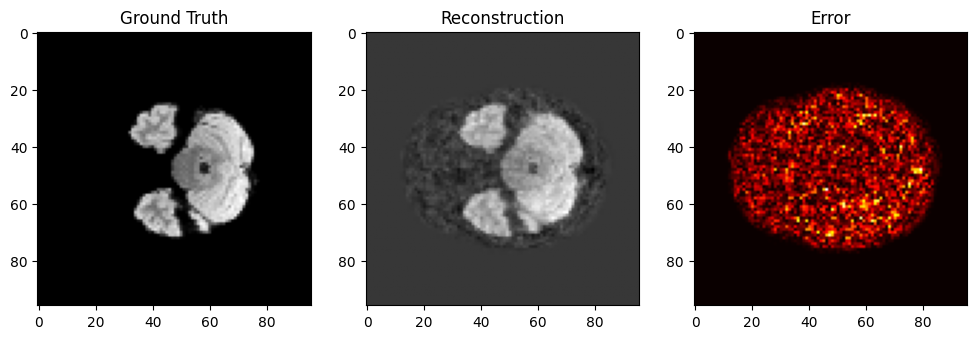

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_small[0],cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,2)
plt.imshow(X_recon[0],cmap="gray")
plt.title("Reconstruction")

plt.subplot(1,3,3)
plt.imshow(abs(X_small[0]-X_recon[0]),cmap="hot")
plt.title("Error")

plt.show()

Resized: (1600, 96, 96)
Latent shape: (1600, 900)
Epoch: 0 Loss: 0.0008264128118753433
Epoch: 100 Loss: 2.427885920042172e-05
Epoch: 200 Loss: 2.0004736143164337e-05
Epoch: 300 Loss: 2.034069984802045e-05
Epoch: 400 Loss: 1.9246735973865725e-05
Epoch: 500 Loss: 1.6913605577428825e-05
Epoch: 600 Loss: 1.5311818060581572e-05
Epoch: 700 Loss: 1.6509549823240377e-05
Average PSNR: 44.274917352441335
Average SSIM: 0.9942627049069679


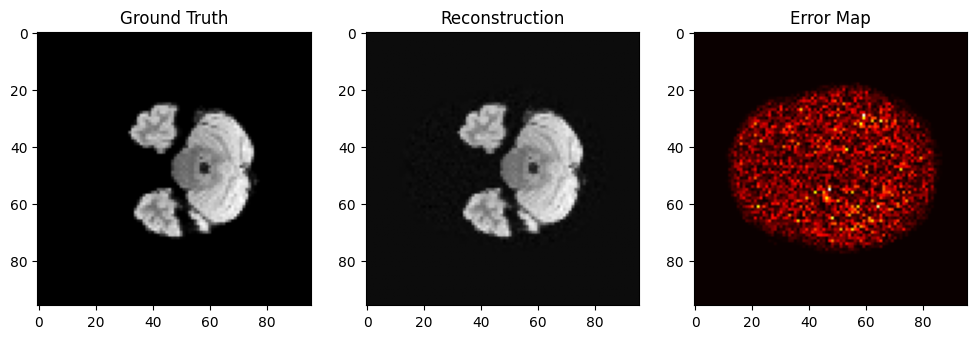

In [ ]:
# =========================================
# FINAL MRI RECONSTRUCTION PIPELINE
# PCA + DEEP AUTOENCODER
# =========================================

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ==============================
# Resize
# ==============================

X_small = np.array([cv2.resize(img,(96,96)) for img in X])

print("Resized:", X_small.shape)


# ==============================
# Normalize
# ==============================

mean = X_small.mean()
std = X_small.std()

X_small = (X_small - mean)/(std + 1e-8)


# ==============================
# PCA Compression
# ==============================

X_vec = X_small.reshape(len(X_small),-1)

pca = PCA(n_components=900)

Z = pca.fit_transform(X_vec)

print("Latent shape:", Z.shape)


# ==============================
# Torch Dataset
# ==============================

Z_tensor = torch.tensor(Z,dtype=torch.float32)

dataset = TensorDataset(Z_tensor)

loader = DataLoader(dataset,batch_size=64,shuffle=True)


# ==============================
# Deep Residual Autoencoder
# ==============================

class Autoencoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(900,1200),
            nn.ReLU(),

            nn.Linear(1200,512),
            nn.ReLU(),

            nn.Linear(512,256)

        )

        self.decoder = nn.Sequential(

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,1200),
            nn.ReLU(),

            nn.Linear(1200,900)

        )

    def forward(self,x):

        z = self.encoder(x)

        recon = self.decoder(z)

        return x + recon   # residual refinement


model = Autoencoder().to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

mse = nn.MSELoss()

l1 = nn.L1Loss()


# ==============================
# Train
# ==============================

for epoch in range(800):

    for batch in loader:

        x = batch[0].to(device)

        recon = model(x)

        loss_mse = mse(recon,x)

        loss_l1 = l1(recon,x)

        loss = 0.7*loss_mse + 0.3*loss_l1

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    if epoch % 100 == 0:

        print("Epoch:",epoch,"Loss:",loss.item())


# ==============================
# Reconstruction
# ==============================

with torch.no_grad():

    refined = model(Z_tensor.to(device)).cpu().numpy()


# ==============================
# Inverse PCA
# ==============================

X_recon = pca.inverse_transform(refined)

X_recon = X_recon.reshape(-1,96,96)


# ==============================
# PSNR / SSIM
# ==============================

psnr_scores=[]
ssim_scores=[]

for i in range(50):

    gt = X_small[i]
    pred = X_recon[i]

    psnr_scores.append(psnr(gt,pred,data_range=gt.max()-gt.min()))

    ssim_scores.append(ssim(gt,pred,data_range=gt.max()-gt.min()))

print("Average PSNR:",np.mean(psnr_scores))
print("Average SSIM:",np.mean(ssim_scores))


# ==============================
# Visualization
# ==============================

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Ground Truth")
plt.imshow(X_small[0],cmap="gray")

plt.subplot(1,3,2)
plt.title("Reconstruction")
plt.imshow(X_recon[0],cmap="gray")

plt.subplot(1,3,3)
plt.title("Error Map")
plt.imshow(abs(X_small[0]-X_recon[0]),cmap="hot")

plt.show()

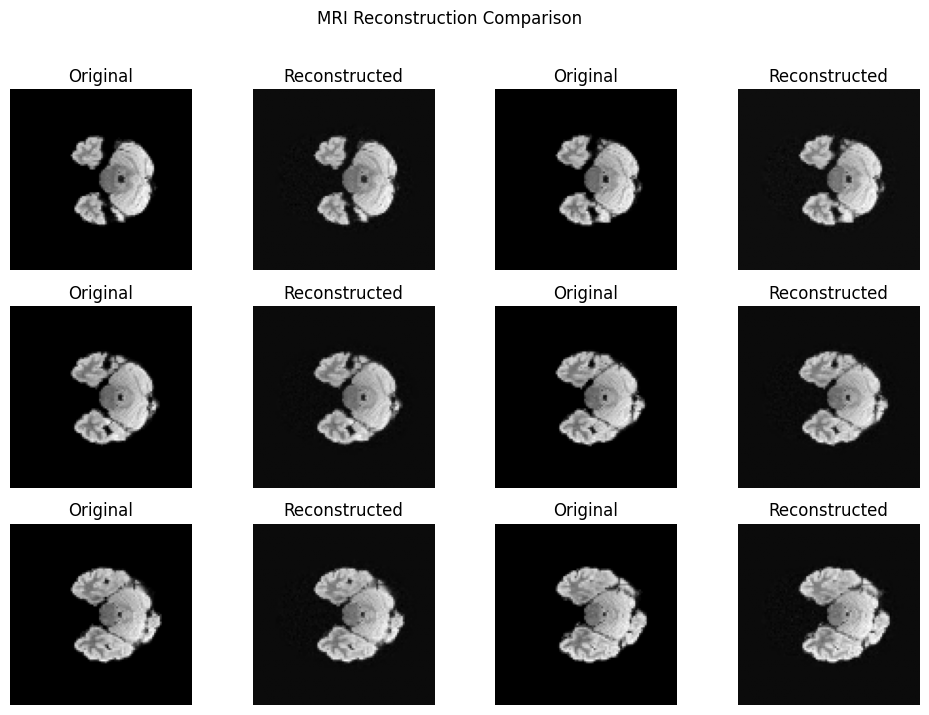

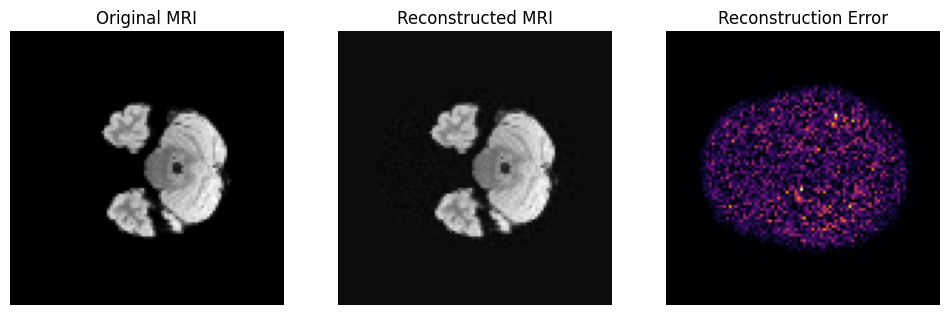

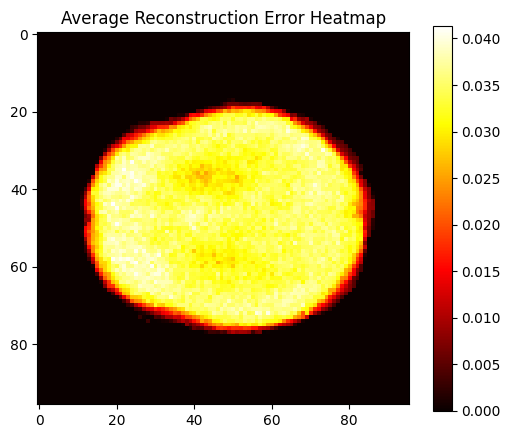

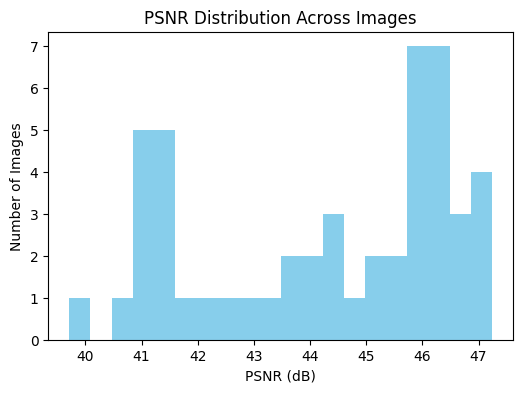

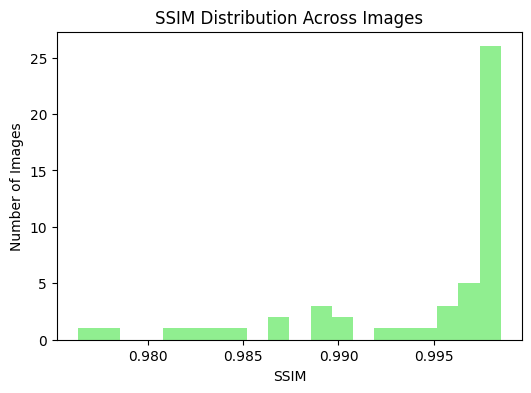

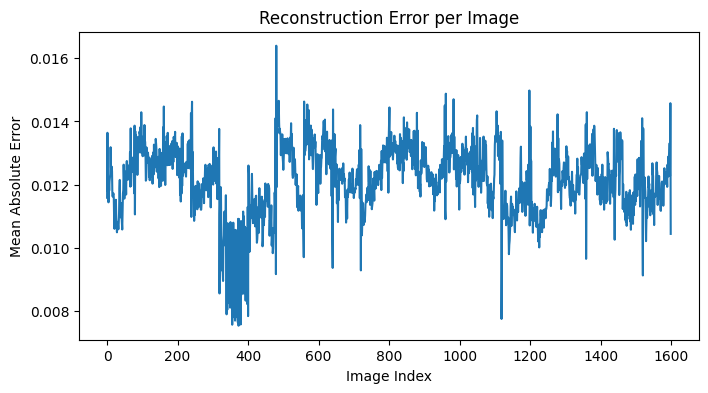

RESULTS SUMMARY
Average PSNR: 44.274917352441335
Average SSIM: 0.9942627049069679
Maximum PSNR: 47.24059777731172
Minimum PSNR: 39.71306617557748
Maximum SSIM: 0.9985233440251567
Minimum SSIM: 0.976320743968859


In [ ]:
# =============================================
# RESULTS VISUALIZATION SECTION
# =============================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------
# 1. Reconstruction Comparison (Multiple Samples)
# ------------------------------------------------

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(3,4,2*i+1)
    plt.imshow(X_small[i], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3,4,2*i+2)
    plt.imshow(X_recon[i], cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.suptitle("MRI Reconstruction Comparison")

plt.show()


# ------------------------------------------------
# 2. Pixel Difference Visualization
# ------------------------------------------------

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_small[0], cmap="gray")
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(X_recon[0], cmap="gray")
plt.title("Reconstructed MRI")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(np.abs(X_small[0] - X_recon[0]), cmap="inferno")
plt.title("Reconstruction Error")
plt.axis("off")

plt.show()


# ------------------------------------------------
# 3. Average Error Heatmap
# ------------------------------------------------

error_map = np.abs(X_small - X_recon)

plt.figure(figsize=(6,5))

plt.imshow(error_map.mean(axis=0), cmap="hot")

plt.title("Average Reconstruction Error Heatmap")

plt.colorbar()

plt.show()


# ------------------------------------------------
# 4. PSNR Distribution
# ------------------------------------------------

plt.figure(figsize=(6,4))

plt.hist(psnr_scores, bins=20, color="skyblue")

plt.title("PSNR Distribution Across Images")

plt.xlabel("PSNR (dB)")
plt.ylabel("Number of Images")

plt.show()


# ------------------------------------------------
# 5. SSIM Distribution
# ------------------------------------------------

plt.figure(figsize=(6,4))

plt.hist(ssim_scores, bins=20, color="lightgreen")

plt.title("SSIM Distribution Across Images")

plt.xlabel("SSIM")
plt.ylabel("Number of Images")

plt.show()


# ------------------------------------------------
# 6. Reconstruction Error Curve
# ------------------------------------------------

errors = [np.mean(np.abs(X_small[i] - X_recon[i])) for i in range(len(X_small))]

plt.figure(figsize=(8,4))

plt.plot(errors)

plt.title("Reconstruction Error per Image")

plt.xlabel("Image Index")
plt.ylabel("Mean Absolute Error")

plt.show()


# ------------------------------------------------
# 7. Metrics Summary
# ------------------------------------------------

print("===================================")
print("RESULTS SUMMARY")
print("===================================")

print("Average PSNR:", np.mean(psnr_scores))
print("Average SSIM:", np.mean(ssim_scores))
print("Maximum PSNR:", np.max(psnr_scores))
print("Minimum PSNR:", np.min(psnr_scores))

print("Maximum SSIM:", np.max(ssim_scores))
print("Minimum SSIM:", np.min(ssim_scores))